## The Greg Method

In [ ]:
# Loaded variable 'df' from URI: /home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/data/claims_train.csv
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
df = pd.read_csv(r'/home/sakul/UNI/3rd Semester/Machine Learning/ITU-MachineLearning-FinalProject-Couriers/data/claims_train.csv')
df.loc[df["Exposure"]>1, "Exposure"] = 1
df = df.loc[df["VehAge"] < 30, :]

df["AgeCategory"] = "Normal"
df.loc[df["DrivAge"] < 25, "AgeCategory"] = "Young"
df.loc[df["DrivAge"] > 70, "AgeCategory"] = "Old"

# Interaction term?
df["Interaction1"] = df["BonusMalus"]/ df["DrivAge"]

# Create column ExposureDays as (Exposure * 365) % 366
df['ExposureDays'] = (df['Exposure'] * 365).round() % 366

# Create TimeBetweenClaims column as ExposureDays/ClaimNb
df['TimeBetweenClaims'] = df['ExposureDays'] / (df['ClaimNb']+1)

df["Risk"] = 1-((df["TimeBetweenClaims"]-df["ExposureDays"])/df["ExposureDays"])-1
df['Risk'] /= df["Exposure"]

df.sort_values("Risk")

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,AgeCategory,Interaction1,ExposureDays,TimeBetweenClaims,Risk
356819,2260634.0,0,0.500000,E,5,3,56,0,B2,Regular,3608,R23,Normal,0.892857,182.0,182.000000,0.0
356811,2134417.0,0,0.080000,C,10,14,35,45,B10,Diesel,136,R53,Normal,2.714286,29.0,29.000000,0.0
356812,1064854.0,0,0.330000,D,9,12,52,26,B1,Regular,1381,R82,Normal,1.461538,120.0,120.000000,0.0
356813,6054645.0,0,0.370000,D,7,2,61,0,B12,Diesel,695,R72,Normal,0.819672,135.0,135.000000,0.0
356814,1041618.0,0,0.330000,C,12,0,32,0,B11,Regular,251,R25,Normal,1.562500,120.0,120.000000,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
70911,7483.0,1,0.002732,B,5,6,28,56,B13,Diesel,51,R24,Normal,3.785714,1.0,0.500000,183.0
250438,9743.0,1,0.002732,D,7,5,42,0,B12,Regular,923,R11,Normal,1.190476,1.0,0.500000,183.0
31389,6138.0,1,0.002732,E,6,0,46,0,B12,Regular,4985,R11,Normal,1.086957,1.0,0.500000,183.0
139795,6384.0,1,0.002732,F,9,0,40,0,B12,Regular,13520,R11,Normal,1.250000,1.0,0.500000,183.0


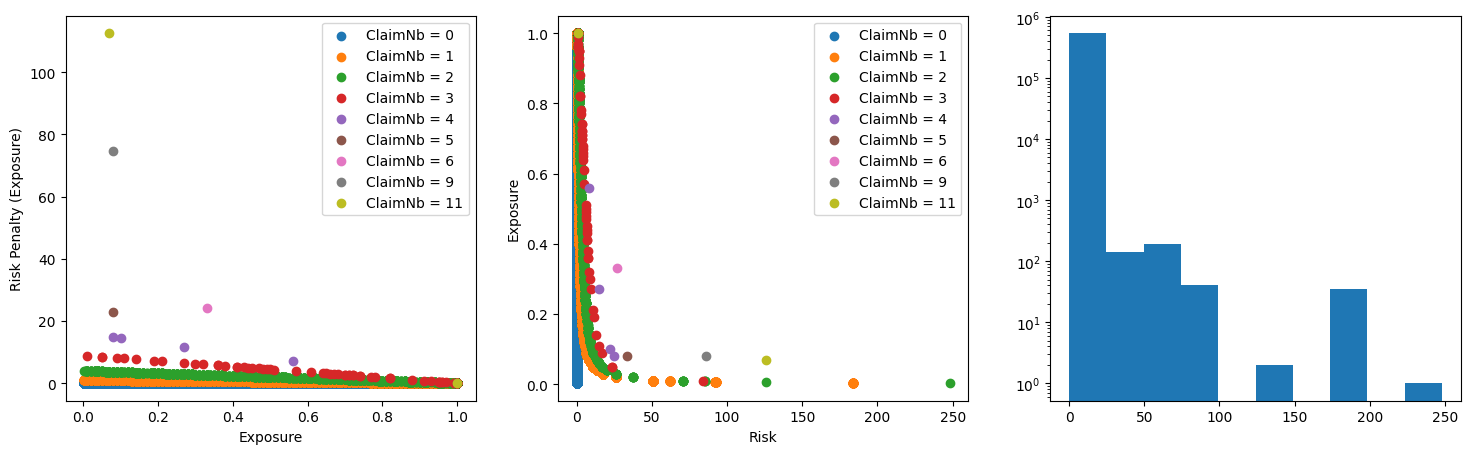

In [94]:
plt.figure(figsize=(18,5))

for i, claimNb in enumerate(sorted(df["ClaimNb"].unique())):
    plt.subplot(1,3,1)
    plt.scatter(df.loc[df["ClaimNb"] == claimNb, ["Exposure"]], ((claimNb**2)*(df["Exposure"].max()-df.loc[df["ClaimNb"] == claimNb, ["Exposure"]])), label = f"ClaimNb = {claimNb}")
    plt.xlabel("Exposure")
    plt.ylabel("Risk Penalty (Exposure)")
    # Adjust Risk Based on Exposure penalty
    df.loc[df["ClaimNb"] == claimNb, "Risk"] += ((claimNb**2)*(df["Exposure"].max()-df.loc[df["ClaimNb"] == claimNb, "Exposure"]))
    plt.legend()
    plt.subplot(1,3,2)
    plt.scatter(df.loc[df["ClaimNb"] == claimNb, ["Risk"]], df.loc[df["ClaimNb"] == claimNb, ["Exposure"]], label = f"ClaimNb = {claimNb}")
    plt.xlabel("Risk")
    plt.ylabel("Exposure")
    plt.legend()
plt.subplot(1,3,3)
plt.hist(df["Risk"])
plt.yscale("log")

In [126]:
df["Risk"] /= df["Risk"].max()


df.sort_values("Risk", inplace=True)
df

df["TimeBetweenClaims"] = 1 - df["TimeBetweenClaims"]/df["TimeBetweenClaims"].max()

(array([128798.,   1271.,   6030.,   4164.,   2579.,   2812.,   7048.,
          2656.,   3118.,   2799.,   7944.,   1353.,   6144.,   9095.,
          3792.,   5711.,   3750.,   6167.,   3410.,   5115.,   7414.,
          1947.,   4627.,  11473.,   2413.,  27622.,   6132.,  13314.,
          3765.,   7991.,   8852.,   3383.,   8305.,   8274.,   9552.,
          5408.,  10462.,  19383.,   4231.,   9609.,  14417.,   3679.,
         10942.,   7733.,  12939.,  10493.,  45752.,  20951.,  10582.,
         15938.]),
 array([0.        , 0.01998174, 0.03996347, 0.05994521, 0.07992694,
        0.09990868, 0.11989041, 0.13987215, 0.15985388, 0.17983562,
        0.19981735, 0.21979909, 0.23978082, 0.25976256, 0.27974429,
        0.29972603, 0.31970776, 0.3396895 , 0.35967123, 0.37965297,
        0.3996347 , 0.41961644, 0.43959817, 0.45957991, 0.47956164,
        0.49954338, 0.51952511, 0.53950685, 0.55948858, 0.57947032,
        0.59945205, 0.61943379, 0.63941553, 0.65939726, 0.679379  ,
        

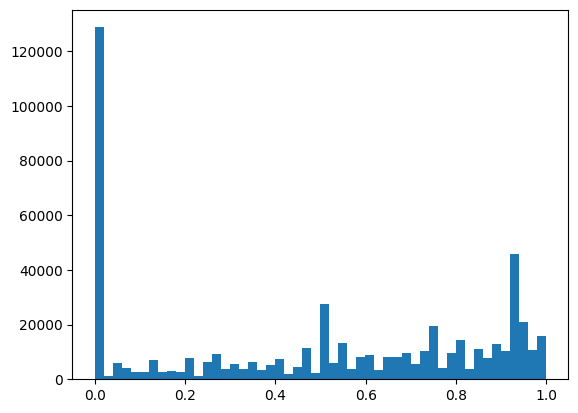

In [102]:
plt.hist(df["TimeBetweenClaims"], bins=50)

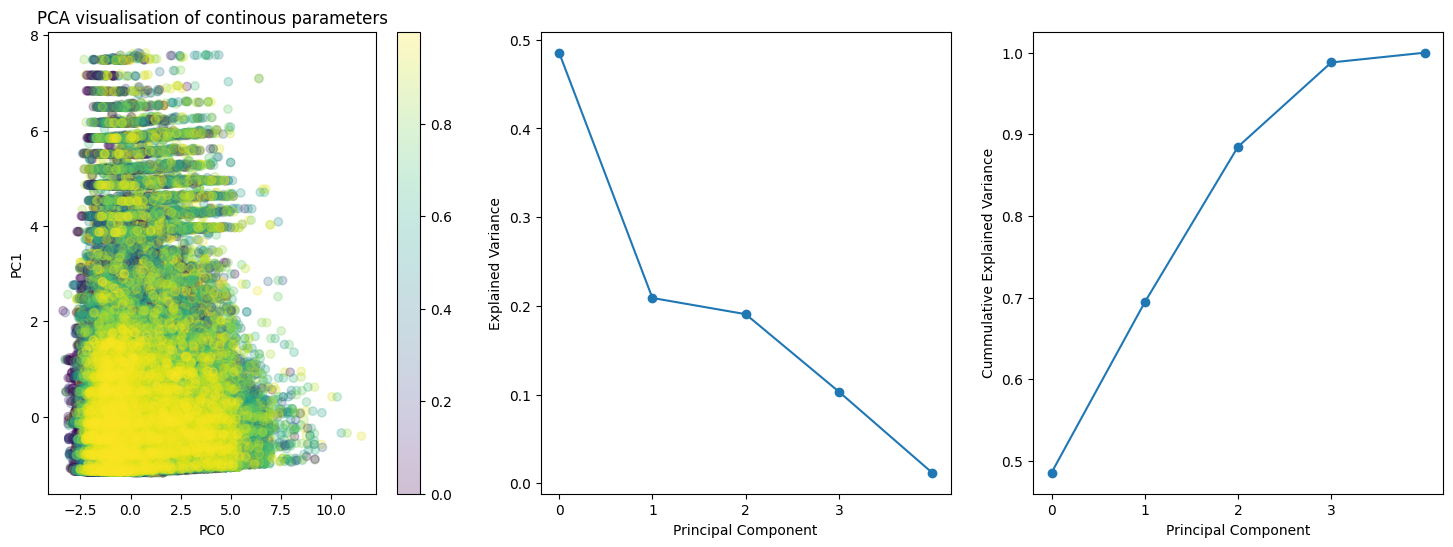

In [127]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


columns2 = ["VehPower", "DrivAge", "BonusMalus", "Density", "Interaction1"]

columns_list = [columns2]

for columns in columns_list:
    plt.figure(figsize=(18, 6))
    ContinousData = pd.DataFrame(StandardScaler().fit_transform(df[columns]), columns=columns)
    pca = PCA().fit(ContinousData)
    pcad = pca.transform(ContinousData)

    plt.subplot(1, 3, 1)
    plt.scatter(pcad[:, 0], pcad[:, 1], c = df["TimeBetweenClaims"], alpha=0.25)
    plt.title("PCA visualisation of continous parameters")
    plt.xlabel("PC0")
    plt.ylabel("PC1")
    plt.colorbar()


    plt.subplot(1, 3, 2)
    plt.plot(pca.explained_variance_ratio_, marker = "o")

    plt.xticks(range(4))
    plt.xlabel("Principal Component")
    plt.ylabel("Explained Variance")
    plt.subplot(1, 3, 3)
    plt.plot([sum(pca.explained_variance_ratio_[:i+1]) for i, ratio in enumerate(pca.explained_variance_ratio_)], marker = "o")
    plt.xticks(range(4))
    plt.xlabel("Principal Component")
    plt.ylabel("Cummulative Explained Variance")


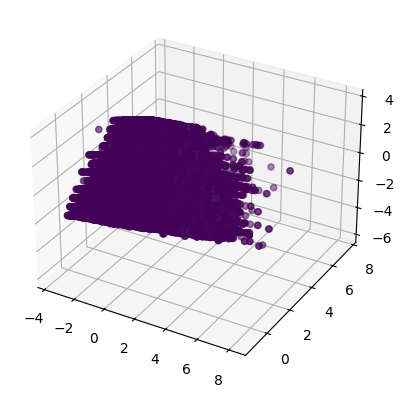

In [5]:

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1, projection="3d")

# Plot the points for the current species
ax.scatter3D(pcad[:, 0], pcad[:, 1], pcad[:, 2], 
            c=df["Risk"])

plt.show()


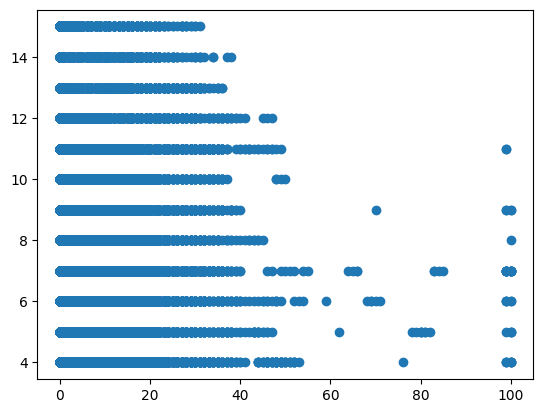

In [6]:
plt.scatter(df["VehAge"], df["VehPower"])